In [14]:
import os
import scanpy as sc
import anndata as ad
import pandas as pd
import time 
import numpy as np
import liana as li
import itertools
import re # spliting the data 
import scipy as sci
from scipy.stats import false_discovery_control
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
adata = sc.read_h5ad('/projects/bioinformatics/DB/scRNAseq_parkinson/dataset.h5ad')

In [4]:
lr_resource = pd.read_csv("/projects/bioinformatics/DB/CellCellCommunication/WithEnzymes/cpdb_cellchat_enz_liana_format.csv")

In [5]:
# here we split them 
def split_genes(gene_entry):
    if pd.isna(gene_entry):
        return []
    
    # split on BOTH "_" and "+"
    genes = re.split(r"[+_]", str(gene_entry))
    
    # remove empty strings if any
    return [g for g in genes if g]

In [6]:
ligand_genes = lr_resource["ligand"].apply(split_genes)
receptor_genes = lr_resource["receptor"].apply(split_genes)

all_genes = set(itertools.chain.from_iterable(ligand_genes)) | \
            set(itertools.chain.from_iterable(receptor_genes))

print("Total unique LR genes:", len(all_genes))

Total unique LR genes: 1576


In [7]:
# Set gene symbols as var_names

adata.var_names = adata.var["gene_name"]

/home/znazari/.conda/envs/liana_scanpy/lib/python3.10/site-packages/anndata/_core/anndata.py:835: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['TNFRSF4', 'TNFRSF18', 'ATAD3B', 'THAP3', 'PRDM16']

    Inferred to be: categorical



In [8]:
# to fix warning 
adata.var_names = adata.var["gene_name"].astype(str)

In [9]:
adata.var_names_make_unique()

In [15]:
genes_in_data = list(set(adata.var_names) & all_genes)

print("Genes found in dataset:", len(genes_in_data))

Genes found in dataset: 1415


In [11]:
# subset 
start = time.time()
adata_lr = adata[:, genes_in_data].copy()
print(adata_lr.shape)
end = time.time()
timing = end - start
print(f'timing:{timing:.2f}second')

(2096155, 1415)
timing:98.58second


In [ ]:
start = time.time()
res_donor = li.method.cellphonedb.by_sample(
    adata_lr,
    groupby="cell_type",
    sample_key="donor_id",   
    resource=lr_resource,
    use_raw=False
)

end = time.time()
timing = end - start
print(f'timing:{timing:.2f}second')


/home/znazari/.conda/envs/liana_scanpy/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/home/znazari/.conda/envs/liana_scanpy/lib/python3.10/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/home/znazari/.conda/envs/liana_scanpy/lib/python3.10/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/home/znazari/.conda/envs/liana_scanpy/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/home/znazari/.conda/envs/liana_scanpy/lib/python3.10/site-packages/liana/method/_pipe_util

# check the cpu usage 

In [ ]:
import os
print(os.getpid())

In [ ]:
res_donor.shape

In [ ]:
res_donor.columns.tolist()

In [13]:
res1 = adata_lr.uns["liana_res"]

In [18]:
res1.to_csv("/projects/bioinformatics/DB/scRNAseq_parkinson/liana_results_sample_modified.csv", index=False)

In [3]:
res1 = pd.read_csv("/projects/bioinformatics/DB/scRNAseq_parkinson/liana_results_sample_modified.csv")

In [5]:
res1

,disease,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
0,normal,NLGN1,NLGN1,5.963885,0.999125,NRXN3,NRXN3,6.199426,0.999746,oligodendrocyte precursor cell,GABAergic neuron,6.081656,0.0
1,normal,NLGN1,NLGN1,5.963885,0.999125,NRXN1,NRXN1,5.933232,0.999083,oligodendrocyte precursor cell,oligodendrocyte precursor cell,5.948559,0.0
2,normal,LRRTM4,LRRTM4,5.563381,0.997374,NRXN3,NRXN3,6.199426,0.999746,oligodendrocyte precursor cell,GABAergic neuron,5.881403,0.0
3,normal,NLGN1,NLGN1,5.963885,0.999125,NRXN1,NRXN1,5.689255,0.999367,oligodendrocyte precursor cell,glutamatergic neuron,5.826570,0.0
4,normal,NRG3,NRG3,6.036231,0.998887,ERBB4,ERBB4,5.509386,0.921737,astrocyte,GABAergic neuron,5.772809,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65251,Parkinson disease,C5,C5,0.165941,0.103910,C5AR1,C5AR1,0.177606,0.111052,glutamatergic neuron,central nervous system neuron,0.171773,1.0
65252,Parkinson disease,WNT8A,WNT8A,0.156221,0.103258,SFRP1,SFRP1,0.187223,0.102392,central nervous system neuron,central nervous system neuron,0.171722,0.0
65253,Parkinson disease,PYY,PYY,0.170627,0.112251,NPY5R,NPY5R,0.168829,0.108387,central nervous system neuron,central nervous system neuron,0.169728,0.0
65254,Parkinson disease,HLA-A,HLA-A,0.175738,0.106003,CD8A,CD8A,0.160177,0.102710,glutamatergic neuron,glutamatergic neuron,0.167958,1.0


In [6]:
# apply FDR correction
res1["cellphone_fdr"] = false_discovery_control(
    res1["cellphone_pvals"].values,
    method="bh"
    
)

In [7]:
res1

,disease,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals,cellphone_fdr
0,normal,NLGN1,NLGN1,5.963885,0.999125,NRXN3,NRXN3,6.199426,0.999746,oligodendrocyte precursor cell,GABAergic neuron,6.081656,0.0,0.0
1,normal,NLGN1,NLGN1,5.963885,0.999125,NRXN1,NRXN1,5.933232,0.999083,oligodendrocyte precursor cell,oligodendrocyte precursor cell,5.948559,0.0,0.0
2,normal,LRRTM4,LRRTM4,5.563381,0.997374,NRXN3,NRXN3,6.199426,0.999746,oligodendrocyte precursor cell,GABAergic neuron,5.881403,0.0,0.0
3,normal,NLGN1,NLGN1,5.963885,0.999125,NRXN1,NRXN1,5.689255,0.999367,oligodendrocyte precursor cell,glutamatergic neuron,5.826570,0.0,0.0
4,normal,NRG3,NRG3,6.036231,0.998887,ERBB4,ERBB4,5.509386,0.921737,astrocyte,GABAergic neuron,5.772809,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65251,Parkinson disease,C5,C5,0.165941,0.103910,C5AR1,C5AR1,0.177606,0.111052,glutamatergic neuron,central nervous system neuron,0.171773,1.0,1.0
65252,Parkinson disease,WNT8A,WNT8A,0.156221,0.103258,SFRP1,SFRP1,0.187223,0.102392,central nervous system neuron,central nervous system neuron,0.171722,0.0,0.0
65253,Parkinson disease,PYY,PYY,0.170627,0.112251,NPY5R,NPY5R,0.168829,0.108387,central nervous system neuron,central nervous system neuron,0.169728,0.0,0.0
65254,Parkinson disease,HLA-A,HLA-A,0.175738,0.106003,CD8A,CD8A,0.160177,0.102710,glutamatergic neuron,glutamatergic neuron,0.167958,1.0,1.0


In [12]:
# filter properly (those that are significant!)

significant_lr = res1[
    (res1["cellphone_fdr"] < 0.05) &
    (res1["ligand_props"] > 0.1) &
    (res1["receptor_props"] > 0.1)
]

In [13]:
significant_lr

,disease,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals,cellphone_fdr
0,normal,NLGN1,NLGN1,5.963885,0.999125,NRXN3,NRXN3,6.199426,0.999746,oligodendrocyte precursor cell,GABAergic neuron,6.081656,0.0,0.0
1,normal,NLGN1,NLGN1,5.963885,0.999125,NRXN1,NRXN1,5.933232,0.999083,oligodendrocyte precursor cell,oligodendrocyte precursor cell,5.948559,0.0,0.0
2,normal,LRRTM4,LRRTM4,5.563381,0.997374,NRXN3,NRXN3,6.199426,0.999746,oligodendrocyte precursor cell,GABAergic neuron,5.881403,0.0,0.0
3,normal,NLGN1,NLGN1,5.963885,0.999125,NRXN1,NRXN1,5.689255,0.999367,oligodendrocyte precursor cell,glutamatergic neuron,5.826570,0.0,0.0
4,normal,NRG3,NRG3,6.036231,0.998887,ERBB4,ERBB4,5.509386,0.921737,astrocyte,GABAergic neuron,5.772809,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65248,Parkinson disease,HLA-F,HLA-F,0.192334,0.100483,CD8A,CD8A,0.160177,0.102710,GABAergic neuron,glutamatergic neuron,0.176255,0.0,0.0
65250,Parkinson disease,WNT8A,WNT8A,0.156221,0.103258,FRZB,FRZB,0.189166,0.113783,central nervous system neuron,central nervous system neuron,0.172694,0.0,0.0
65252,Parkinson disease,WNT8A,WNT8A,0.156221,0.103258,SFRP1,SFRP1,0.187223,0.102392,central nervous system neuron,central nervous system neuron,0.171722,0.0,0.0
65253,Parkinson disease,PYY,PYY,0.170627,0.112251,NPY5R,NPY5R,0.168829,0.108387,central nervous system neuron,central nervous system neuron,0.169728,0.0,0.0


In [32]:
# Make a copy
df = significant_lr.copy()

# Average communication strength per disease and cell-cell interaction
cell_comm = (
    df.groupby(
        ['disease', 'source', 'target']
    )['lr_means']
    .mean()
    .reset_index()
)

cell_comm.head()

,disease,source,target,lr_means
0,Parkinson disease,GABAergic neuron,GABAergic neuron,1.438220
1,Parkinson disease,GABAergic neuron,astrocyte,1.412555
2,Parkinson disease,GABAergic neuron,central nervous system macrophage,1.117717
3,Parkinson disease,GABAergic neuron,central nervous system neuron,1.375114
4,Parkinson disease,GABAergic neuron,endothelial cell,1.307053


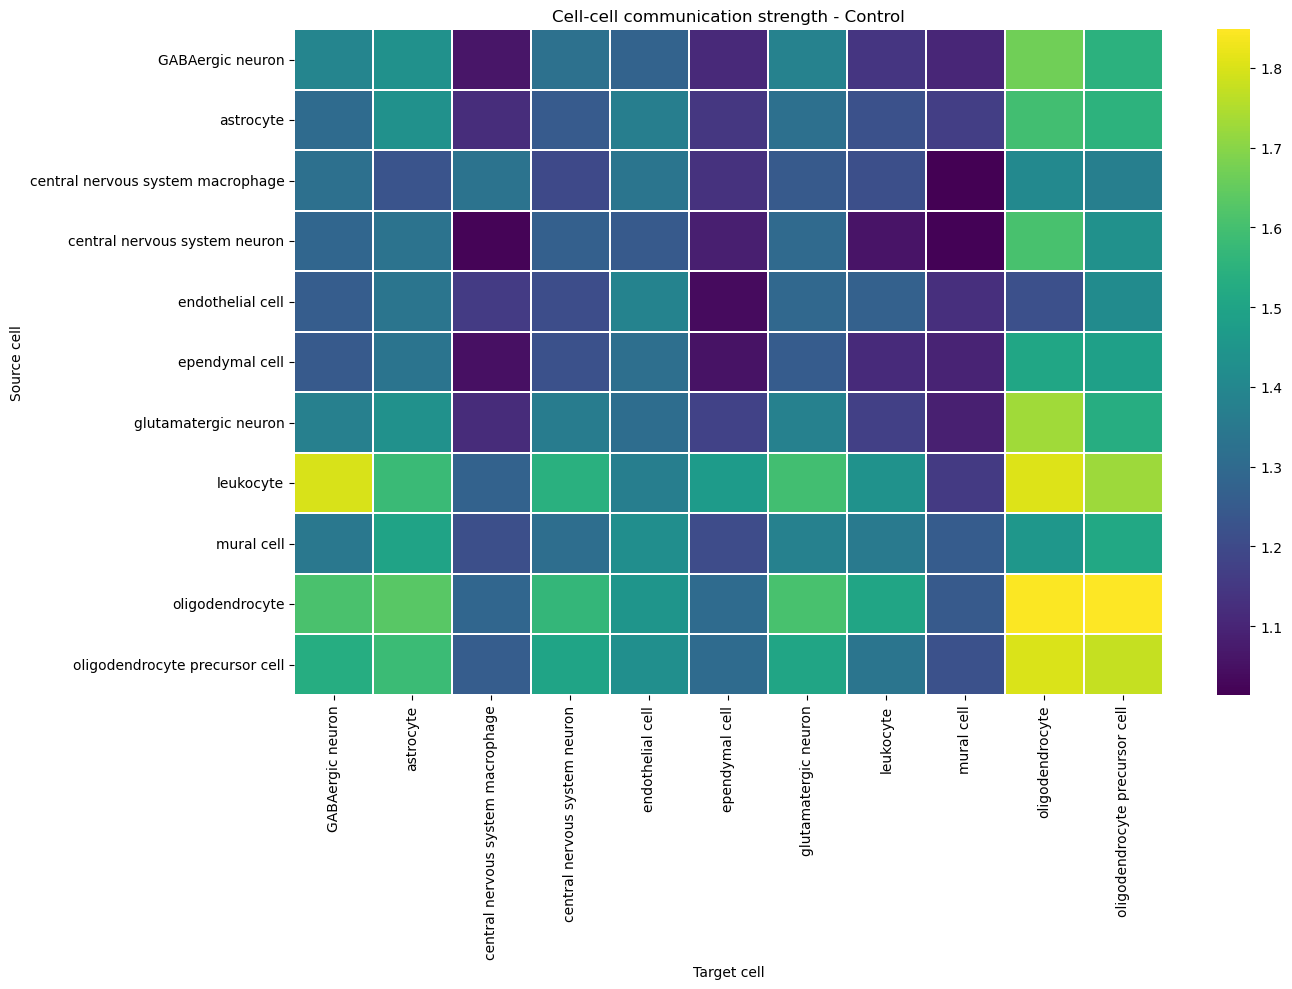

In [33]:
# control

normal_matrix = (
    cell_comm[cell_comm['disease']=="normal"]
    .pivot(
        index="source",
        columns="target",
        values="lr_means"
    )
)


plt.figure(figsize=(14,10))

sns.heatmap(
    normal_matrix,
    cmap="viridis",
    linewidths=0.2
)

plt.title("Cell-cell communication strength - Control")
plt.xlabel("Target cell")
plt.ylabel("Source cell")
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

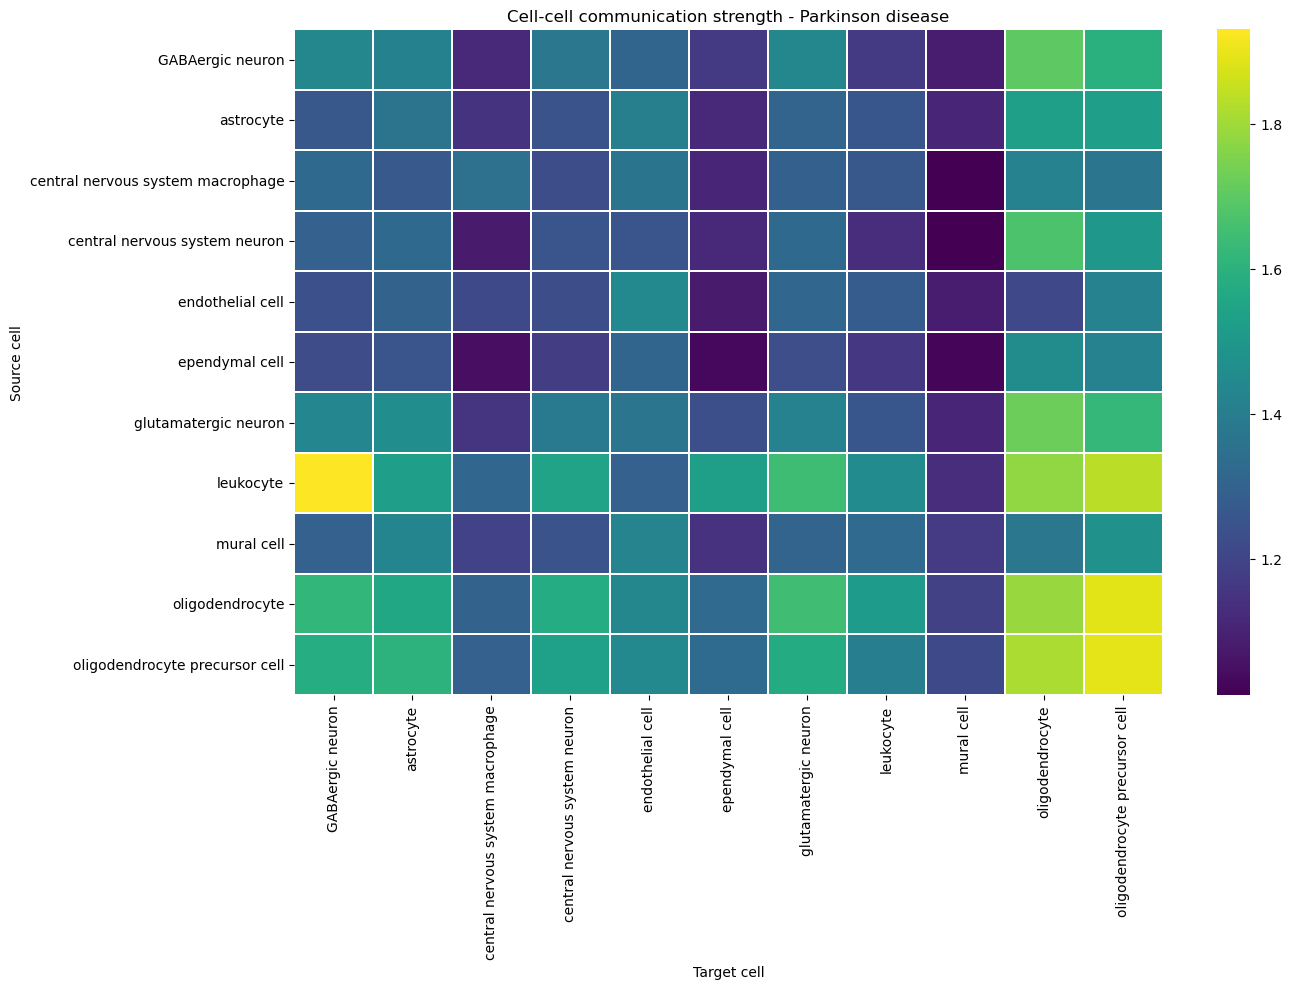

In [34]:
# Parkinson's disease 

pd_matrix = (
    cell_comm[cell_comm['disease']=="Parkinson disease"]
    .pivot(
        index="source",
        columns="target",
        values="lr_means"
    )
)


plt.figure(figsize=(14,10))

sns.heatmap(
    pd_matrix,
    cmap="viridis",
    linewidths=0.2
)

plt.title("Cell-cell communication strength - Parkinson disease")
plt.xlabel("Target cell")
plt.ylabel("Source cell")
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

# plot Parkinson - Control difference

In [36]:
common_cells = list(
    set(normal_matrix.index)
    .intersection(pd_matrix.index)
)

normal_matrix = normal_matrix.loc[common_cells, common_cells]
pd_matrix = pd_matrix.loc[common_cells, common_cells]


difference = pd_matrix - normal_matrix

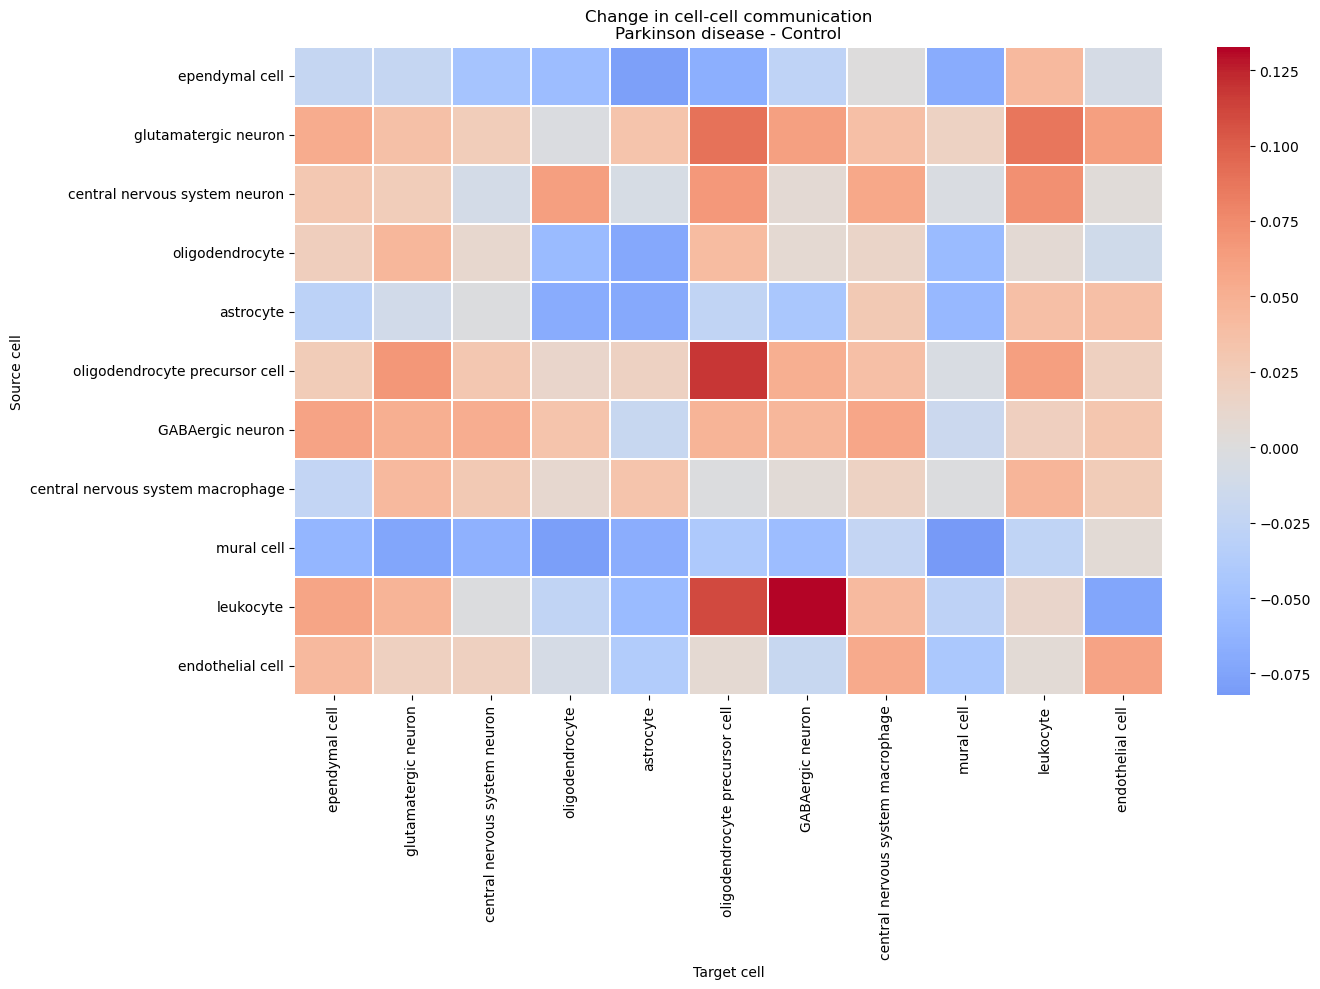

In [37]:
plt.figure(figsize=(14,10))

sns.heatmap(
    difference,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Change in cell-cell communication\nParkinson disease - Control")
plt.xlabel("Target cell")
plt.ylabel("Source cell")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Interpretation:

🔴 positive values → stronger communication in Parkinson
🔵 negative values → reduced communication in Parkinson